# Executive Summary: Marketing Campaign Analysis

### Project Goal
The primary objective of this project is to analyze customer demographic, financial, and behavioral data from a banking marketing campaign. By identifying the key drivers that lead to a successful "Subscription" (Target = Yes), this analysis provides data-driven strategies to optimize future marketing efforts and maximize conversion rates.

### Key Findings (Top 3)
1. **The Power of Previous Success:** Customers who converted in previous campaigns have a **64% conversion rate** in the current campaign, compared to the overall average of ~12%. Historical success is the strongest predictor of future behavior.
2. **Engagement is Critical:** There is a direct correlation between **Call Duration** and conversion. Successfully converted customers have significantly higher average call durations, indicating that engagement quality is a key driver of sales.
3. **High-Value Segments:** Customers without **housing loans** and those with **University degrees** represent the most receptive segments, showing nearly double the conversion rates of other demographic groups.

###  Final Result & Impact
* **Identified Class Imbalance:** Noted a significant imbalance (88.2% No vs 11.8% Yes), highlighting the need for targeted rather than mass-marketing approaches.
* **Strategic Optimization:** Provided actionable recommendations to shift focus toward high-propensity segments (previous successes and high-education groups), which can lead to a more efficient allocation of marketing budget and higher ROI.

## Data Dictionary

| Column Category | Feature Name | Description |
| :--- | :--- | :--- |
| **Identification** | `id` | Unique identifier for each customer record. |
| **Demographic** | `age` | Age of the customer. |
| | `gender` | Gender of the customer (Male/Female). |
| | `job` | Type of job (Management, Technician, Blue-collar, etc.). |
| | `marital` | Marital status (Married, Single, Divorced). |
| | `education` | Education level (Primary, Secondary, Tertiary, Unknown). |
| **Financial** | `balance` | Average yearly balance in Euros. |
| | `accountBalance` | Specific current balance in the customer's account. |
| | `default` | Has credit in default? (Yes/No). |
| | `housing` | Has a housing loan? (Yes/No). |
| | `loan` | Has a personal loan? (Yes/No). |
| **Campaign** | `contact` | Communication type (Cellular, Telephone, Unknown). |
| | `day` | Last contact day of the month. |
| | `month` | Last contact month of the year. |
| | `duration` | Last contact duration in seconds. |
| | `campaign` | Number of contacts performed during this current campaign. |
| | `numberOfContacts` | Total frequency of contacts made for this specific customer. |
| **History** | `pdays` | Days since the customer was last contacted (-1 = never contacted). |
| | `daySinceLastCampaign` | Specific interval of days since the previous campaign outreach. |
| | `previous` | Number of contacts performed before this campaign. |
| | `poutcome` | Outcome of the previous marketing campaign (Success/Failure). |
| **Target** | `target` | **Has the client subscribed? (Yes/No)** |

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
data = pd.read_csv("traindata.csv")

In [3]:
data.head()

,id,target,day,month,duration,contactId,age,gender,job,maritalStatus,education,creditFailure,accountBalance,house,credit,contactType,numberOfContacts,daySinceLastCampaign,numberOfContactsLastCampaign,lastCampaignResult
0,432148809,no,27,may,166,623,30,female,worker,married,highSchool,no,-202,no,no,unknown,2,NaN,0,unknown
1,432184318,no,26,oct,183,1992,42,female,manager,married,uniGraduated,no,2463,no,no,cellPhone,2,NaN,0,unknown
2,432182482,no,5,jun,227,2778,26,female,services,single,highSchool,no,2158,yes,yes,landline,1,NaN,0,unknown
3,432150520,no,2,jun,31,3070,34,male,unemployed,divorced,uniGraduated,yes,75,yes,no,unknown,3,NaN,0,unknown
4,432145870,no,15,may,1231,6583,48,male,worker,married,secondarySchool,no,559,yes,no,unknown,2,NaN,0,unknown


In [31]:
data.shape

(31480, 21)

In [4]:
data.tail()

,id,target,day,month,duration,contactId,age,gender,job,maritalStatus,education,creditFailure,accountBalance,house,credit,contactType,numberOfContacts,daySinceLastCampaign,numberOfContactsLastCampaign,lastCampaignResult
31475,432184725,yes,30,nov,1628,69542367,58,female,technical,married,highSchool,no,3399,no,no,landline,2,188.0,8,success
31476,432147139,no,21,may,173,69542565,40,female,manager,single,secondarySchool,no,858,yes,no,unknown,1,NaN,0,unknown
31477,432166958,no,17,nov,422,69543453,51,female,worker,married,highSchool,no,1414,yes,no,unknown,3,186.0,2,failure
31478,432166312,no,29,aug,69,69544121,30,male,technical,married,uniGraduated,no,1,no,no,cellPhone,21,NaN,0,unknown
31479,432171709,no,2,feb,171,69546604,50,male,technical,divorced,highSchool,no,8,no,no,cellPhone,2,5.0,1,other


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31480 entries, 0 to 31479
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            31480 non-null  int64  
 1   target                        31480 non-null  object 
 2   day                           31480 non-null  int64  
 3   month                         31480 non-null  object 
 4   duration                      31480 non-null  int64  
 5   contactId                     31480 non-null  int64  
 6   age                           31480 non-null  int64  
 7   gender                        31480 non-null  object 
 8   job                           31480 non-null  object 
 9   maritalStatus                 31480 non-null  object 
 10  education                     31480 non-null  object 
 11  creditFailure                 31480 non-null  object 
 12  accountBalance                31480 non-null  int64  
 13  h

In [7]:
data.describe()

,id,day,duration,contactId,age,accountBalance,numberOfContacts,daySinceLastCampaign,numberOfContactsLastCampaign
count,3.148000e+04,31480.000000,31480.000000,3.148000e+04,31480.000000,31480.000000,31480.000000,5738.000000,31480.000000
mean,4.321650e+08,15.799015,258.498380,3.464717e+07,40.935737,1348.535133,2.779670,225.272395,0.584339
std,1.304725e+04,8.323251,256.576891,2.011538e+07,10.629198,2974.355578,3.139269,116.488328,2.469742
min,4.321423e+08,1.000000,0.000000,6.230000e+02,18.000000,-8019.000000,1.000000,1.000000,0.000000
25%,4.321536e+08,8.000000,104.000000,1.709904e+07,33.000000,70.000000,1.000000,133.000000,0.000000
50%,4.321650e+08,16.000000,180.000000,3.468141e+07,39.000000,442.000000,2.000000,195.000000,0.000000
75%,4.321762e+08,21.000000,320.000000,5.204811e+07,48.000000,1410.000000,3.000000,327.000000,0.000000
max,4.321876e+08,31.000000,4918.000000,6.954660e+07,95.000000,98417.000000,63.000000,871.000000,275.000000


In [8]:
data.isnull().sum()

id                                  0
target                              0
day                                 0
month                               0
duration                            0
contactId                           0
age                                 0
gender                              0
job                                 0
maritalStatus                       0
education                           0
creditFailure                       0
accountBalance                      0
house                               0
credit                              0
contactType                         0
numberOfContacts                    0
daySinceLastCampaign            25742
numberOfContactsLastCampaign        0
lastCampaignResult                  0
dtype: int64

In [9]:
# Handle missing values

data['daySinceLastCampaign'] = data['daySinceLastCampaign'].fillna(-1)

In [10]:
# Handle duplicate values

data.duplicated().sum()


np.int64(0)

## EDA-Exploratory Data Analysis

### Marketing Campaign Analysis Overview

##### This project aims to analyze customer behavior in a marketing campaign and identify key factors influencing subscription outcomes. By examining demographic, financial, and historical campaign data, the analysis provides actionable insights to improve marketing effectiveness and conversion rates.

## OVERALL PERFORMANCE

### Customer Conversion Distribution

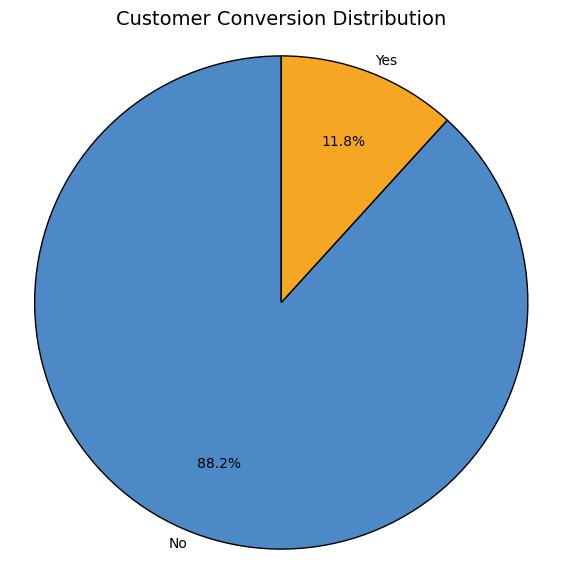

In [11]:
# Data
target_counts = data['target'].value_counts()
labels = ['No', 'Yes']
sizes = target_counts.values

# Colors (same as your example)
colors = ['#4C89C6', '#F5A623']  # Soft blue & warm orange

# Create figure
plt.figure(figsize=(7,7))

# Pie chart
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.7,      
    labeldistance=1.05,   
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

# Title
plt.title('Customer Conversion Distribution', fontsize=14)

# Perfect circle
plt.axis('equal')

plt.show()

### Key Insights :
The distribution of customer responses reveals a significant class imbalance, where approximately 88.2% of customers did not subscribe, while only 11.8% converted successfully.This indicates that the marketing campaign faces a low overall conversion rate, which is typical in large-scale outreach campaigns but highlights a critical opportunity for optimization.

## CUSTOMER DEMOGRAPHIC PROFILE

### Customer Demographic Profile

To understand who the customers are, we analyze key demographic characteristics including gender, marital status, job, and education.

### Gender Distribution of Customers

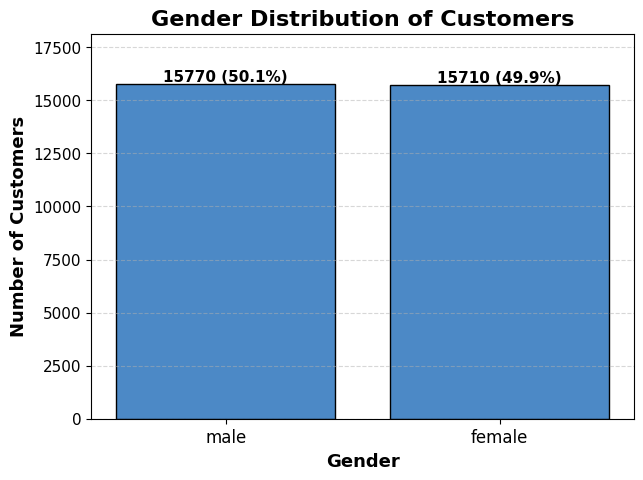

In [12]:
# Data
gender_counts = data['gender'].value_counts()
labels = gender_counts.index
values = gender_counts.values

# Create figure
plt.figure(figsize=(7,5))

# Bars
bars = plt.bar(labels, values, color='#4C89C6', edgecolor='black')

# Add space on top
plt.ylim(0, max(values) * 1.15)

# Add value + percentage labels
total = sum(values)
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Title
plt.title('Gender Distribution of Customers', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Gender', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Tick styling
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Key Insighsts : 
The dataset is evenly distributed between male (50.1%) and female (49.9%) customers, indicating no gender imbalance.

### Marital Status Distribution of Customers

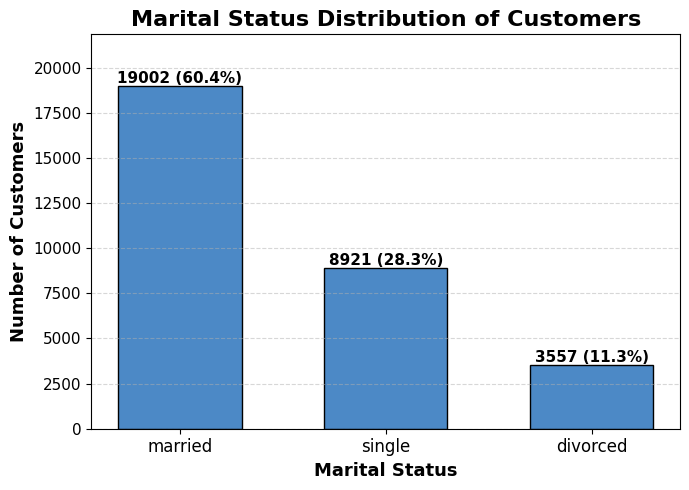

In [13]:
# Data
marital_counts = data['maritalStatus'].value_counts()

labels = marital_counts.index
values = marital_counts.values

# Create figure
plt.figure(figsize=(7,5))

# Bars
bars = plt.bar(labels, values, color='#4C89C6', edgecolor='black', width=0.6)

# Add top spacing 
plt.ylim(0, max(values) * 1.15)

# Add value + percentage labels
total = sum(values)
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Title
plt.title('Marital Status Distribution of Customers', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Marital Status', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Tick styling
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insights :
Married customers dominate the dataset, representing 60.4% of total observations, followed by single customers at 28.3%, while divorced individuals account for only 11.3%, indicating a significant imbalance in marital status distribution.

### Job Distribution of Customers

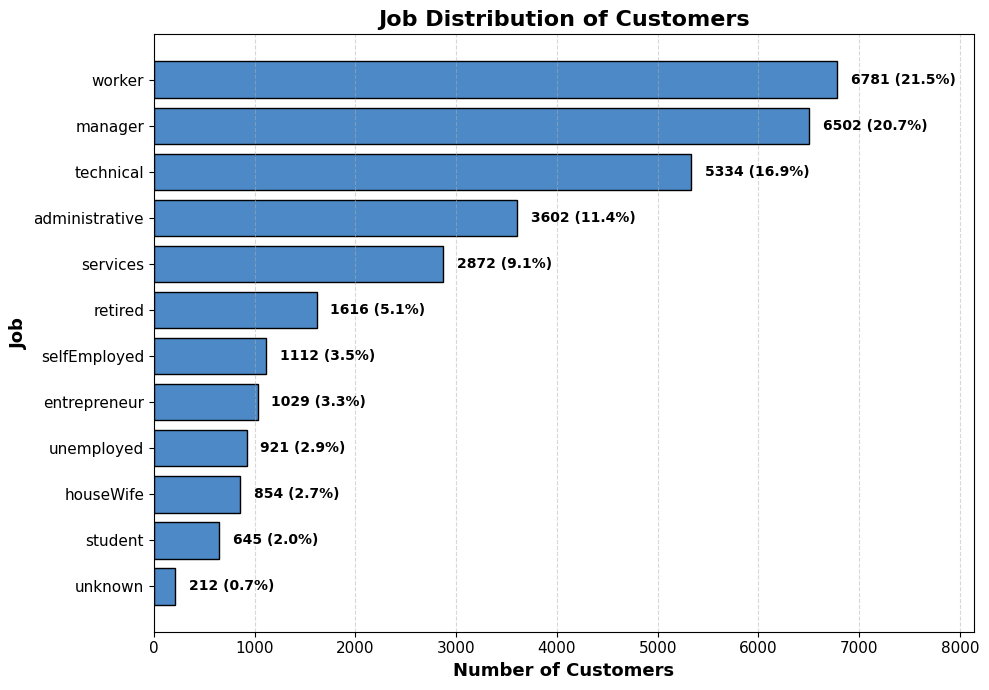

In [14]:
# Data
job_counts = data['job'].value_counts().sort_values()

labels = job_counts.index
values = job_counts.values

# Create figure
plt.figure(figsize=(10,7))

# Bars
bars = plt.barh(labels, values, color='#4C89C6', edgecolor='black')

# Add right-side spacing
plt.xlim(0, max(values) * 1.20)

# Add value + percentage labels
total = sum(values)
for bar in bars:
    width = bar.get_width()
    percent = (width / total) * 100
    plt.text(width + max(values)*0.02,
             bar.get_y() + bar.get_height()/2,
             f'{int(width)} ({percent:.1f}%)',
             va='center', fontsize=10, fontweight='bold')

# Title
plt.title('Job Distribution of Customers', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Number of Customers', fontsize=13, fontweight='bold')
plt.ylabel('Job', fontsize=13, fontweight='bold')

# Tick styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insights :
The majority of customers belong to working professions such as workers (21.5%), managers (20.7%), and technical roles (16.9%).

### Detailed Analysis :
The dataset shows a clear concentration of customers in a few dominant job categories. The majority of customers are workers (21.5%), followed by managers (20.7%) and technical professionals (16.9%), indicating strong representation of working-class and professional individuals.
Mid-level representation is observed among administrative and service roles, while smaller segments include students, housewives, and unemployed individuals.
This suggests that the dataset is skewed toward economically active groups, which may influence model predictions and marketing strategies.

### Education Level Distribution of Customers

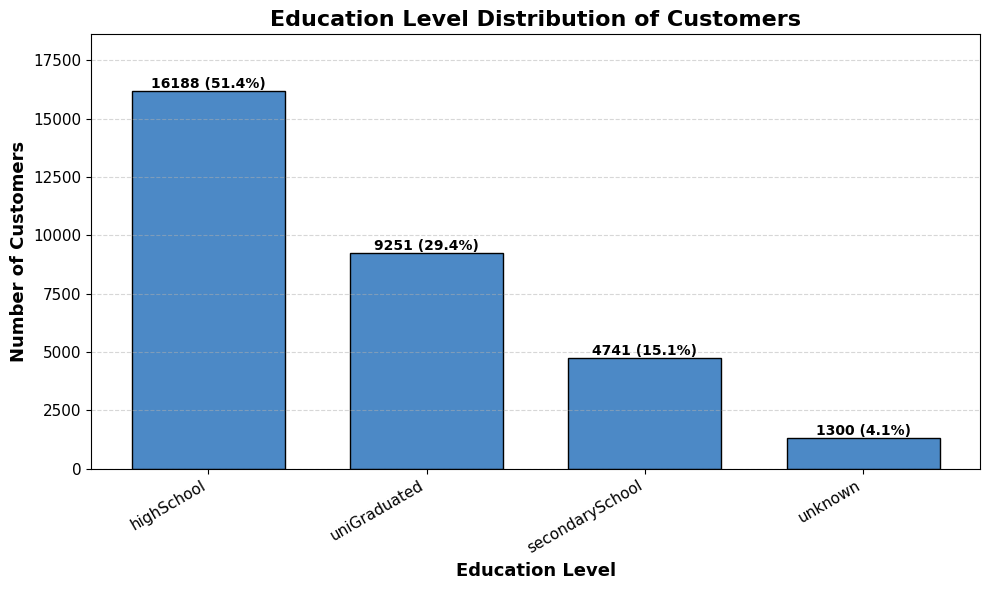

In [15]:
# Data
edu_counts = data['education'].value_counts()

labels = edu_counts.index
values = edu_counts.values

# Create figure
plt.figure(figsize=(10,6))

# Bars
bars = plt.bar(labels, values, color='#4C89C6', edgecolor='black', width=0.7)

# Add top spacing
plt.ylim(0, max(values) * 1.15)

# Add value + percentage labels
total = sum(values)
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Title
plt.title('Education Level Distribution of Customers', fontsize=16, fontweight='bold')

# Axis labels 
plt.xlabel('Education Level', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Rotate labels
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insight :
Customers are predominantly from a high school background, accounting for 51.4% (16188) of the dataset, followed by university graduates at 29.4% (9251), while secondary school (15.1% (4741)) and unknown education levels (4.1% (1300)) represent smaller segments.

## FINANCIAL PROFILE

### Customer Financial Status

### Housing Loan Distribution Among Customers

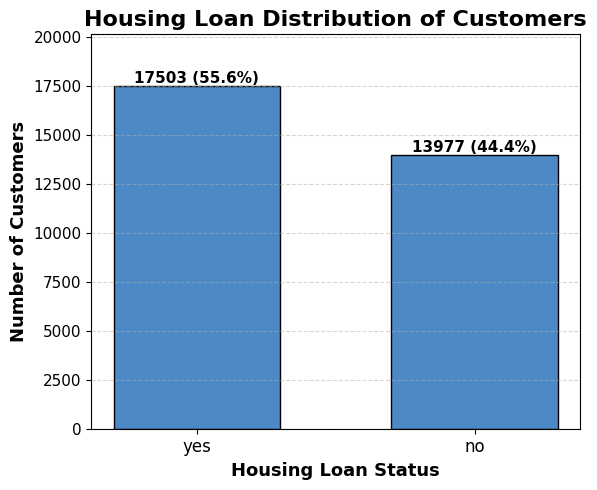

In [16]:
# Data
house_counts = data['house'].value_counts()

labels = house_counts.index
values = house_counts.values

# Create figure
plt.figure(figsize=(6,5))

# Bars
bars = plt.bar(labels, values, color='#4C89C6', edgecolor='black', width=0.6)

# Add top spacing
plt.ylim(0, max(values) * 1.15)

# Add value + percentage labels
total = sum(values)
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Title
plt.title('Housing Loan Distribution of Customers', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Housing Loan Status', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Tick styling
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insight :
Customers with housing loans represent the majority with 17503 (55.6%), compared to 13977 (44.4%) customers without housing loans, indicating that a slightly larger portion of the customer base is financially committed through housing loans.

### Credit Failure Status Distribution of Customers

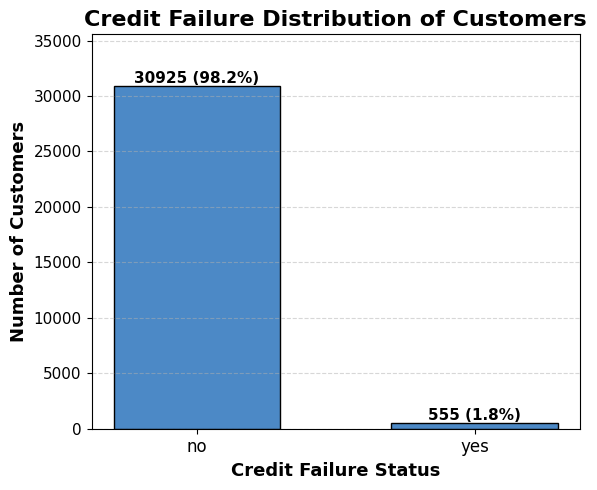

In [17]:
# Data
credit_counts = data['creditFailure'].value_counts()

labels = credit_counts.index
values = credit_counts.values

# Create figure
plt.figure(figsize=(6,5))

# Bars
bars = plt.bar(labels, values, color='#4C89C6', edgecolor='black', width=0.6)

# Add top spacing
plt.ylim(0, max(values) * 1.15)

# Add value + percentage labels
total = sum(values)
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Title
plt.title('Credit Failure Distribution of Customers', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Credit Failure Status', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Tick styling
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insight :
The dataset is overwhelmingly dominated by customers without credit failure, accounting for 98.2% (30925), while only a very small proportion of customers 1.8% (555) have a history of credit failure, indicating overall financial stability

## CAMPAIGN BEHAVIOR

### Distribution of Previous Campaign Outcomes

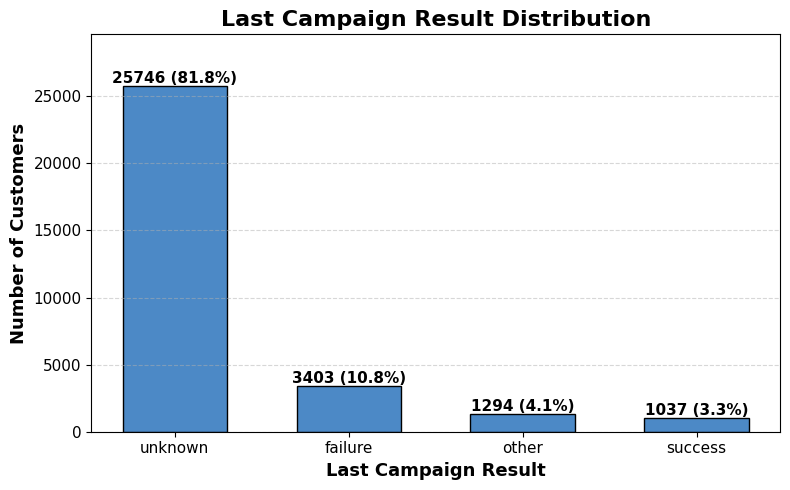

In [18]:
# Data
last_counts = data['lastCampaignResult'].value_counts()

labels = last_counts.index
values = last_counts.values

# Create figure
plt.figure(figsize=(8,5))

# Bars
bars = plt.bar(labels, values, color='#4C89C6', edgecolor='black', width=0.6)

# Add top spacing
plt.ylim(0, max(values) * 1.15)

# Add value + percentage labels
total = sum(values)
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Title
plt.title('Last Campaign Result Distribution', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Last Campaign Result', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Tick styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insights :
The majority of customers fall under the ‘unknown’ category with 25746 (81.8%), while very few customers had a successful previous campaign outcome at only 1037 (3.3%), indicating limited prior campaign success and missing historical engagement data.

### Impact of Previous Campaign Outcome on Customer Conversion

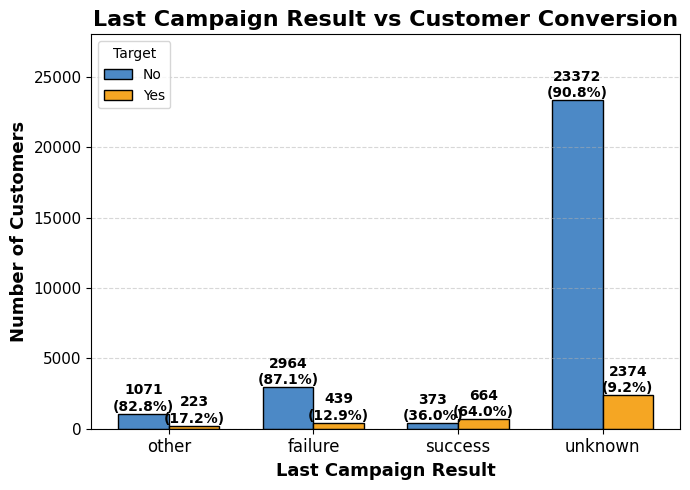

In [19]:
# Create count table
ct = pd.crosstab(data['lastCampaignResult'], data['target'])
ct.columns = ['No', 'Yes']

# sort for better readability
ct = ct.sort_values(by='Yes')

labels = ct.index
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))

# Bars
bars1 = plt.bar(x - width/2, ct['No'], width,
                label='No', color='#4C89C6', edgecolor='black')
bars2 = plt.bar(x + width/2, ct['Yes'], width,
                label='Yes', color='#F5A623', edgecolor='black')

# Add spacing
plt.ylim(0, ct.values.max() * 1.20)

# Totals
totals = ct.sum(axis=1)

# Add labels (value + %)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Title
plt.title('Last Campaign Result vs Customer Conversion', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Last Campaign Result', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Ticks
plt.xticks(x, labels, fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
plt.legend(title='Target')

plt.tight_layout()
plt.savefig("campaign_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

### Key Insight :
Customers with a previously successful campaign show the highest conversion rate at 664 (64.0%), compared to 439 (12.9%) for failures and only 2374 (9.2%) for unknown outcomes, highlighting the strong influence of prior success on customer conversion.

### Detailed Analysis :
- Customers with previous campaign success have the highest conversion rate, with 664 (64.0%) converting and only 373 (36.0%) not converting.
- Customers with a ‘failure’ history show significantly lower conversion, with 439 (12.9%) conversions and 2964 (87.1%) non-conversions.
- The ‘unknown’ category dominates in size, but conversion is low at 2374 (9.2%), while 23372 (90.8%) did not convert.
- The ‘other’ category also shows low engagement, with only 223 (17.2%) conversions compared to 1071 (82.8%) non-conversions.
- There is a clear pattern: past success strongly increases future conversion probability, while failure or unknown history leads to lower engagement.

### Business Implication :
- Customers with previous success should be prioritized as a high-value target segment for future campaigns.
- Retargeting strategies can be highly effective for this group, given their proven responsiveness (64.0%).
- Customers with past failures require improved messaging or different campaign strategies.
- The large ‘unknown’ segment presents an opportunity for first-time engagement optimization.
- Previous campaign outcome is one of the most powerful predictors and should be heavily weighted in predictive models.

## FEATURE IMPACT ANALYSIS

### Key Factors Influencing Customer Conversion

### Impact of Marital Status on Customer Conversion

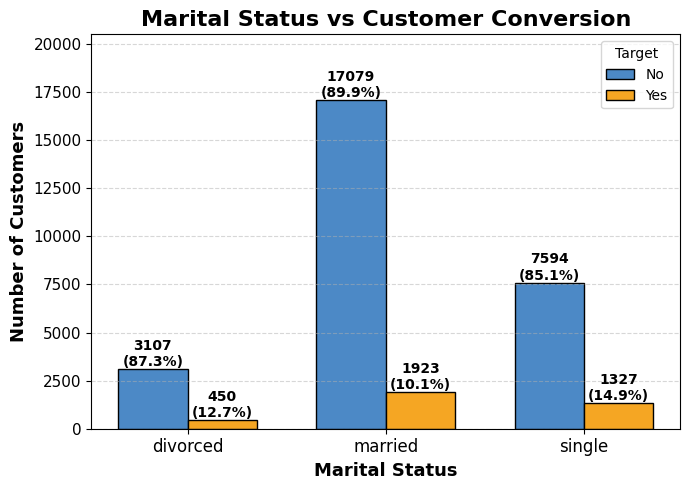

In [20]:
# Create count table
ct = pd.crosstab(data['maritalStatus'], data['target'])
ct.columns = ['No', 'Yes']

labels = ct.index
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))

# Bars
bars1 = plt.bar(x - width/2, ct['No'], width,
                label='No', color='#4C89C6', edgecolor='black')
bars2 = plt.bar(x + width/2, ct['Yes'], width,
                label='Yes', color='#F5A623', edgecolor='black')

# Add spacing 
plt.ylim(0, ct.values.max() * 1.20)

# Totals
totals = ct.sum(axis=1)

# Labels (value + %)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Title
plt.title('Marital Status vs Customer Conversion', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Marital Status', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Ticks
plt.xticks(x, labels, fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
plt.legend(title='Target')

plt.tight_layout()
plt.show()

### Key Insights :
Single customers exhibit the highest conversion rate at 14.9%, followed by divorced customers at 12.7%, while married customers show the lowest conversion rate at 10.1%, despite representing the largest segment. This indicates that smaller segments are relatively more responsive to the campaign.

### Detailed Analysis :
- Married customers have the largest customer base, with 17079 (89.9%) not subscribing and 1923 (10.1%) subscribing, indicating the lowest conversion      rate among all groups.
- Single customers show comparatively better engagement, with 7594 (85.1%) not subscribing and 1327 (14.9%) subscribing, representing the highest          conversion rate.
- Divorced customers have a smaller segment size, with 3107 (87.3%) not subscribing and 450 (12.7%) subscribing, showing moderate conversion               performance
- Despite being the dominant group in size, married customers exhibit lower responsiveness to the campaign compared to smaller segments
- The variation in conversion rates across marital status groups indicates that customer behavior differs significantly by segment


### Business Implication :
- Marketing campaigns targeting single customers may yield higher returns due to their stronger conversion rate
- Married customers, despite their large volume, may require more personalized or optimized strategies to improve engagement
- Divorced customers represent a moderate opportunity segment that can be proved with targeted messaging
- Segment-based marketing should be prioritized, as one-size-fits-all campaigns may reduce effectiveness
- Understanding these behavioral differences can help improve conversion optimization and campaign ROI

### Conversion Outcome by Gender

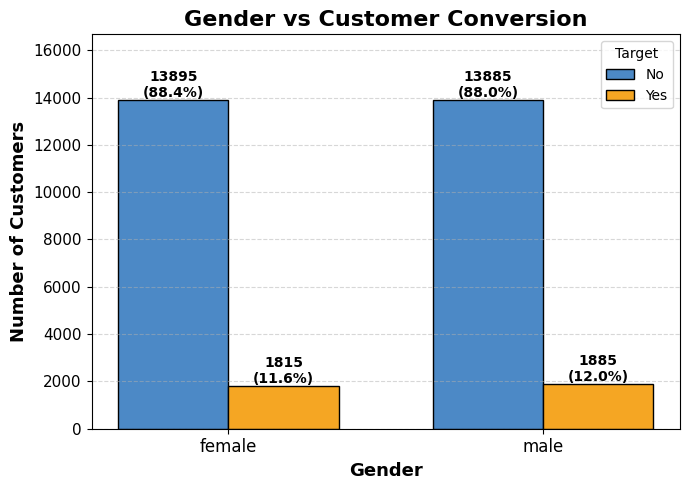

In [21]:
# Create count table
ct = pd.crosstab(data['gender'], data['target'])
ct.columns = ['No', 'Yes']

labels = ct.index
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))

bars1 = plt.bar(x - width/2, ct['No'], width, label='No',
                color='#4C89C6', edgecolor='black')
bars2 = plt.bar(x + width/2, ct['Yes'], width, label='Yes',
                color='#F5A623', edgecolor='black')

# Add spacing
plt.ylim(0, ct.values.max() * 1.20)

totals = ct.sum(axis=1)

for i, bar in enumerate(bars1):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.title('Gender vs Customer Conversion', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

plt.xticks(x, labels, fontsize=12)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Target')

plt.tight_layout()
plt.show()

### Key Insights :
Both male and female customers exhibit very similar conversion behavior, with approximately 11–12% subscribing and around 88% not converting, indicating that gender has minimal impact on subscription outcomes.

### Education Level Impact on Customer Conversion

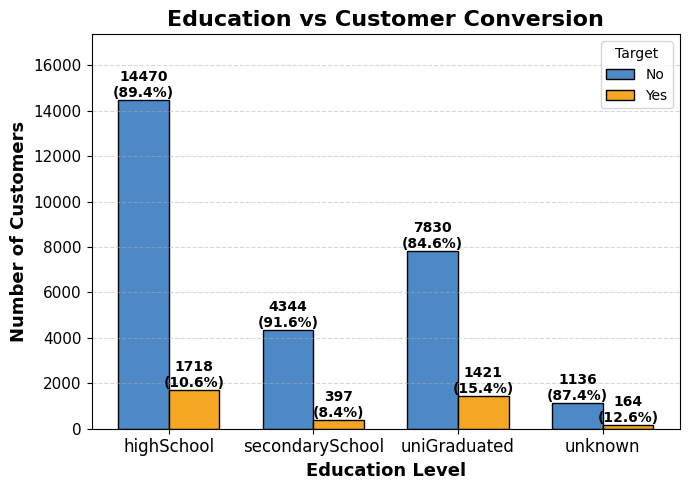

In [22]:
# Create count table
ct = pd.crosstab(data['education'], data['target'])
ct.columns = ['No', 'Yes']

labels = ct.index
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))

# Bars
bars1 = plt.bar(x - width/2, ct['No'], width,
                label='No', color='#4C89C6', edgecolor='black')
bars2 = plt.bar(x + width/2, ct['Yes'], width,
                label='Yes', color='#F5A623', edgecolor='black')

# Add spacing
plt.ylim(0, ct.values.max() * 1.20)

# Totals
totals = ct.sum(axis=1)

# Add labels (value + %)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Title
plt.title('Education vs Customer Conversion', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Education Level', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Ticks
plt.xticks(x, labels, fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
plt.legend(title='Target')

plt.tight_layout()
plt.show()

### Key insights :
University graduates show the highest conversion rate at 15.4% (1421), followed by customers with unknown education at 12.6% (164) and high school at 10.6% (1718), while secondary school customers have the lowest conversion rate at 8.4% (397).

### Detailed Analysis
- University graduates demonstrate the strongest performance, with 1421 (15.4%) conversions compared to 7830 (84.6%) non-conversions
- High school customers form a large segment, with 1718 (10.6%) conversions and 14470 (89.4%) non-conversions, but show relatively lower conversion        efficiency
- Secondary school customers have the weakest response, with only 397 (8.4%) conversions against 4344 (91.6%) non-conversions
- The unknown education group shows moderate performance, with 164 (12.6%) conversions and 1136 (87.4%) non-conversions
- Conversion rates vary noticeably across education levels, indicating that education plays a role in customer responsiveness

### Business Implication
- Marketing campaigns targeting university graduates may achieve higher conversion rates due to stronger engagement
- High school customers, despite their size, require better targeting strategies to improve performance
- Secondary school segments may need revised messaging or campaign optimization due to low responsiveness
- The unknown group should be further analyzed or refined for better segmentation accuracy
- ducation-based segmentation can significantly improve campaign effectiveness and ROI

### Conversion Outcome by Job Category

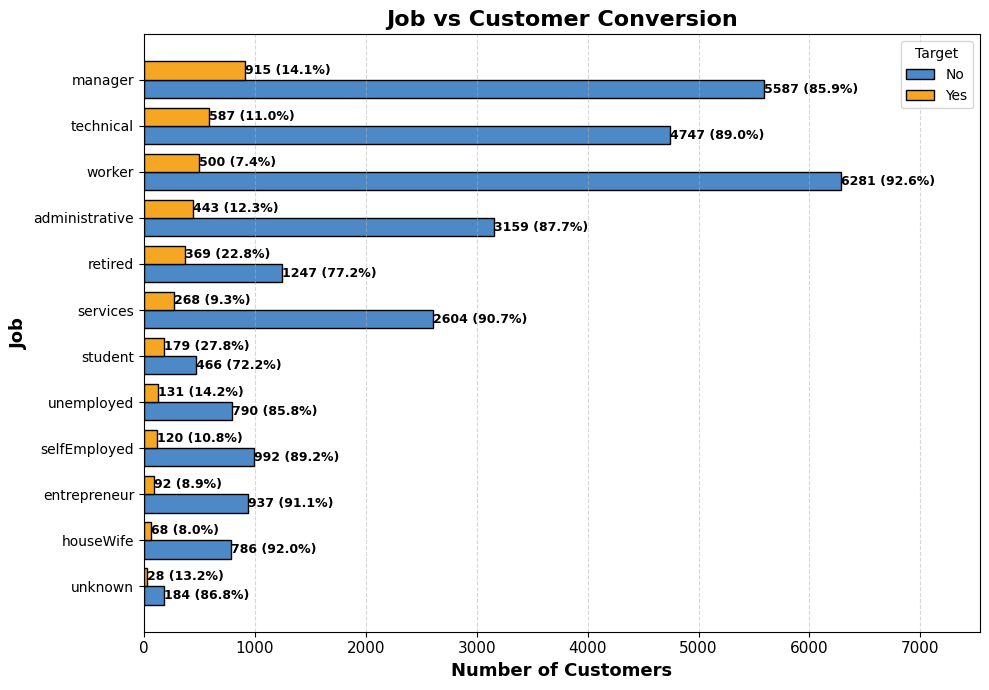

In [23]:
# Create count table
ct = pd.crosstab(data['job'], data['target'])
ct.columns = ['No', 'Yes']

# Sort for better readability
ct = ct.sort_values(by='Yes')

labels = ct.index
y = np.arange(len(labels))
height = 0.4

plt.figure(figsize=(10,7))

# Bars
bars1 = plt.barh(y - height/2, ct['No'], height,
                 label='No', color='#4C89C6', edgecolor='black')
bars2 = plt.barh(y + height/2, ct['Yes'], height,
                 label='Yes', color='#F5A623', edgecolor='black')

# Add spacing
plt.xlim(0, ct.values.max() * 1.20)

# Total per job
totals = ct.sum(axis=1)

# Add labels (value + %)
for i, bar in enumerate(bars1):
    width_val = bar.get_width()
    percent = (width_val / totals.iloc[i]) * 100
    plt.text(width_val,
             bar.get_y() + bar.get_height()/2,
             f'{int(width_val)} ({percent:.1f}%)',
             va='center', fontsize=9, fontweight='bold')

for i, bar in enumerate(bars2):
    width_val = bar.get_width()
    percent = (width_val / totals.iloc[i]) * 100
    plt.text(width_val,
             bar.get_y() + bar.get_height()/2,
             f'{int(width_val)} ({percent:.1f}%)',
             va='center', fontsize=9, fontweight='bold')

# Title
plt.title('Job vs Customer Conversion', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Number of Customers', fontsize=13, fontweight='bold')
plt.ylabel('Job', fontsize=13, fontweight='bold')

# Ticks
plt.yticks(y, labels, fontsize=10)
plt.xticks(fontsize=11)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Legend
plt.legend(title='Target')

plt.tight_layout()
plt.show()

### Key insights :
Students and retired customers show the highest conversion rates, while workers and services roles have comparatively lower subscription rates.

### Detailed Analysis :
- Conversion behavior varies significantly across job categories, indicating that job type is an important factor influencing customer subscription      decisions
- Students (~27.8%) and retired individuals (~22.8%) exhibit the highest conversion rates, suggesting higher responsiveness to marketing campaigns
- Managers (~14.1%) and administrative roles (~12.3%) show moderate conversion performance
- Workers (~7.4%) and services roles (~9.3%) demonstrate comparatively lower conversion rates despite having the largest population share
- Most job categories still show a high proportion of “No” responses, reflecting the overall class imbalance in the dataset

### Business Implication :
- Campaigns could be more effective when targeting students and retired customers
- High-volume segments like workers may require different messaging or personalized strategies to improve conversion
- ob-based segmentation can significantly enhance marketing efficiency and overall ROI

### Impact of Housing Loan on Customer Conversion

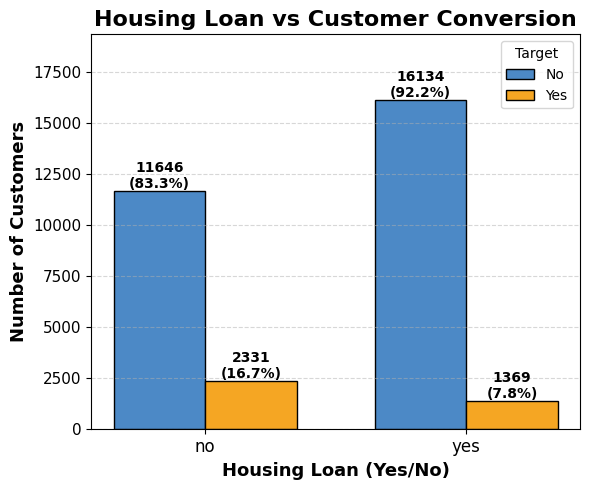

In [24]:

# Create count table
ct = pd.crosstab(data['house'], data['target'])
ct.columns = ['No', 'Yes']

labels = ct.index
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,5))

# Bars
bars1 = plt.bar(x - width/2, ct['No'], width,
                label='No', color='#4C89C6', edgecolor='black')
bars2 = plt.bar(x + width/2, ct['Yes'], width,
                label='Yes', color='#F5A623', edgecolor='black')

# Add spacing
plt.ylim(0, ct.values.max() * 1.20)

# Totals
totals = ct.sum(axis=1)

# Add labels (value + %)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Title
plt.title('Housing Loan vs Customer Conversion', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Housing Loan (Yes/No)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Ticks
plt.xticks(x, labels, fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
plt.legend(title='Target')

plt.tight_layout()
plt.show()

### Key Insight : 
Customers without housing loans show a significantly higher conversion rate at 2331 (16.7%), compared to 1369 (7.8%) among customers with housing loans, indicating that customers without financial commitments are more likely to subscribe.

### Detailed Analysis :
- Customers without housing loans have a total of 2331 conversions (16.7%), which is more than double the conversion rate of customers with housing        loans
- Customers with housing loans show lower engagement, with only 1369 conversions (7.8%), despite being a large segment
- Non-loan customers also have a lower non-conversion count (11646 / 83.3%) compared to loan holders (16134 / 92.2%), indicating better responsiveness
- Customers with housing loans are more likely to decline subscription offers, as reflected by their higher non-conversion percentage
- The data clearly highlights that financial obligations negatively influence subscription behavior

### Business Implication :
- Customers without housing loans represent a high-potential target segment for marketing campaigns
- Campaign strategies should be adjusted for loan holders, possibly focusing on lower-risk or more flexible financial products
- Housing loan status is a critical predictor variable for customer conversion and should be included in modeling
- Businesses can improve ROI by prioritizing low financial-burden segments
- Personalized offers based on financial commitments can significantly enhance conversion optimization

### Credit Failure Impact on Customer Conversion

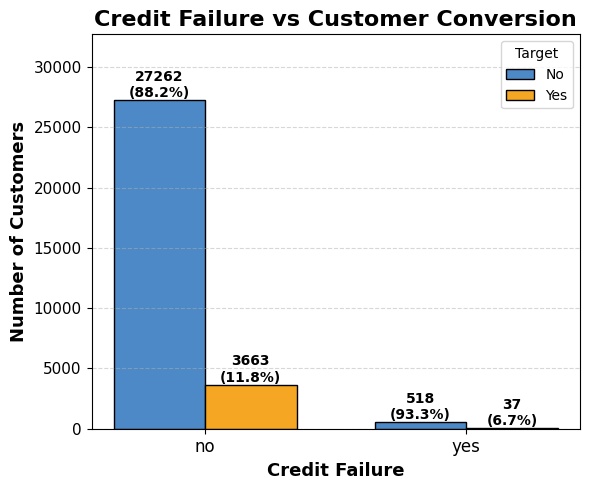

In [25]:
# Create count table
ct = pd.crosstab(data['creditFailure'], data['target'])
ct.columns = ['No', 'Yes']

labels = ct.index
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,5))

# Bars
bars1 = plt.bar(x - width/2, ct['No'], width,
                label='No', color='#4C89C6', edgecolor='black')
bars2 = plt.bar(x + width/2, ct['Yes'], width,
                label='Yes', color='#F5A623', edgecolor='black')

# Add spacing
plt.ylim(0, ct.values.max() * 1.20)

# Totals
totals = ct.sum(axis=1)

# Add labels (value + %)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    percent = (height / totals.iloc[i]) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Title
plt.title('Credit Failure vs Customer Conversion', fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel('Credit Failure', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13, fontweight='bold')

# Ticks
plt.xticks(x, labels, fontsize=12)
plt.yticks(fontsize=11)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
plt.legend(title='Target')

plt.tight_layout()
plt.show()

### Key Insight :
Customers without credit failure show a higher conversion volume with 3663 (11.8%) subscriptions, while customers with credit failure have a significantly lower conversion rate of only 6.7% (37), indicating that prior credit issues negatively impact subscription likelihood.

### Detailed Analysis :
- Customers without credit failure dominate the dataset, with 27262 (88.2%) non-conversions and 3663 (11.8%) conversions
- Customers with credit failure form a very small segment, with 518 (93.3%) non-conversions and only 37 (6.7%) conversions
- The conversion rate for customers without credit failure (11.8%) is nearly double that of customers with credit failure (6.7%)
- Customers with prior credit issues show significantly lower engagement and responsiveness to the campaign
- Credit history appears to be a strong factor influencing customer decision-making behavior

### Business Implication :
- Customers without credit failure should be the primary target segment for maximizing campaign conversions
- Customers with credit failure may require specialized financial offers or tailored messaging
- Risk-based segmentation can improve campaign efficiency and targeting accuracy
- Financial trust and credibility play a key role in customer conversion behavior
- Incorporating credit-related features can enhance predictive modeling and campaign strategy

## Numerical Feature Overview

#### Correlation Analysis of Numerical Variables

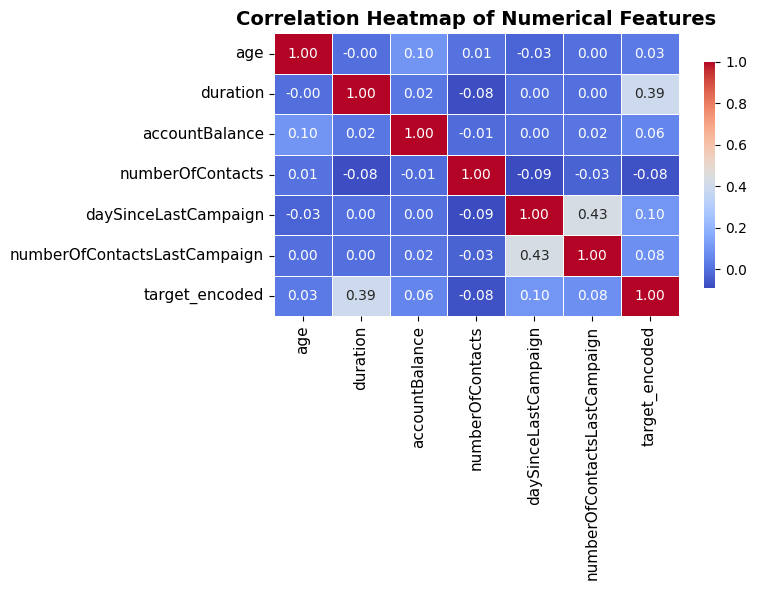

In [26]:
# Correlation Heatmap of Numerical Features

# Encode target variable
data['target_encoded'] = data['target'].map({'no': 0, 'yes': 1})

# Correct numerical columns (based on your dataset)
num_cols = [
    'age',
    'duration',
    'accountBalance',
    'numberOfContacts',
    'daySinceLastCampaign',
    'numberOfContactsLastCampaign',
    'target_encoded'
]

# Correlation matrix
corr = data[num_cols].corr()

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap of Numerical Features',
          fontsize=14, fontweight='bold')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

### Key Insights: Correlation with Target Variable
- Duration shows the strongest positive correlation with the target (0.39), indicating that longer call durations significantly increase the likelihood   of customer conversion.
- Days Since Last Campaign (0.10) and Number of Contacts in Last Campaign (0.08) show weak positive relationships, suggesting that recent engagement      history has a minor influence on conversion.
- Account Balance (0.06) and Age (0.03) have very weak positive correlations, indicating that financial status and age alone are not strong predictors    of conversion.
- Number of Contacts (-0.08) has a slight negative correlation with the target, implying that excessive contact attempts may reduce the probability of    conversion.

## Feature-Level Analysis

### Analysis of Call Duration and Customer Conversion

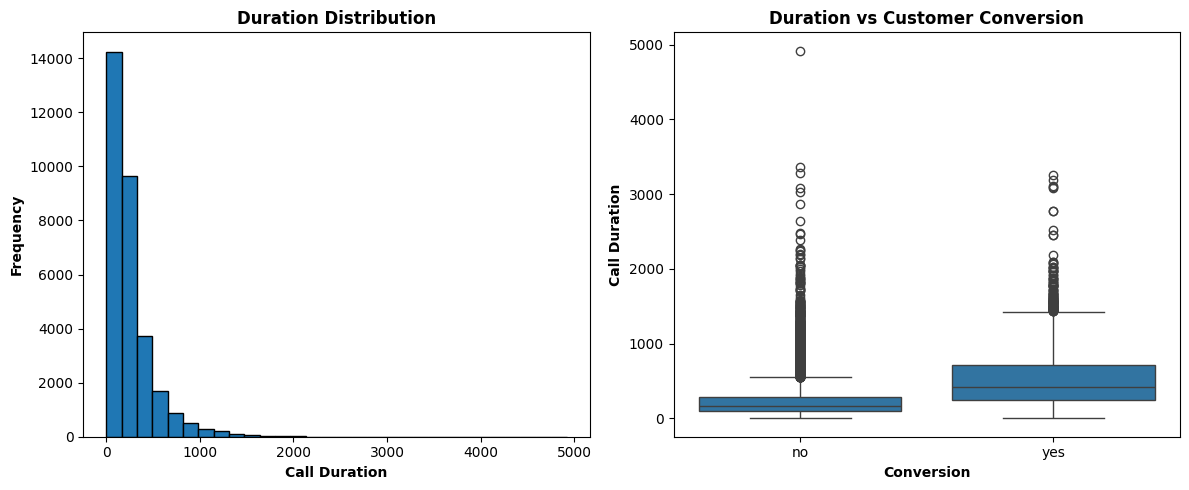

In [27]:
# Distribution and Conversion Analysis of Duration

plt.figure(figsize=(12,5))

# Histogram (Distribution)
plt.subplot(1,2,1)
plt.hist(data['duration'], bins=30, edgecolor='black')
plt.title('Duration Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Call Duration', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')

# Boxplot (vs Target)
plt.subplot(1,2,2)
sns.boxplot(x='target', y='duration', data=data)
plt.title('Duration vs Customer Conversion', fontsize=12, fontweight='bold')
plt.xlabel('Conversion', fontweight='bold')
plt.ylabel('Call Duration', fontweight='bold')

plt.tight_layout()
plt.show()

### Key Insights :
- The distribution of call duration is highly right-skewed, with a large concentration of calls occurring at lower duration values, while a small         number of calls extend to very high durations.
- Customers who converted exhibit significantly higher call durations compared to non-converted customers, indicating a strong positive relationship      between interaction time and conversion likelihood.
- The presence of numerous high-value outliers suggests that longer conversations play a critical role in successful conversions, even though they        occur less frequently.
- Overall, call duration emerges as the most influential numerical feature, highlighting that deeper customer engagement during calls greatly increases   the probability of conversion.

### Business Implications :
- Sales representatives should focus on maintaining longer and more engaging conversations, as increased interaction time directly improves conversion    chances.
- Training programs should emphasize communication quality, customer engagement techniques, and relationship-building skills to extend meaningful call    duration.
- Short-duration calls should be reviewed and optimized, as they are less likely to result in successful conversions.
  Campaign strategies should prioritize quality of interaction over quantity, ensuring that customer conversations are informative and persuasive         rather than brief and transactional.

### Impact of Campaign Contact Frequency on Customer Conversion

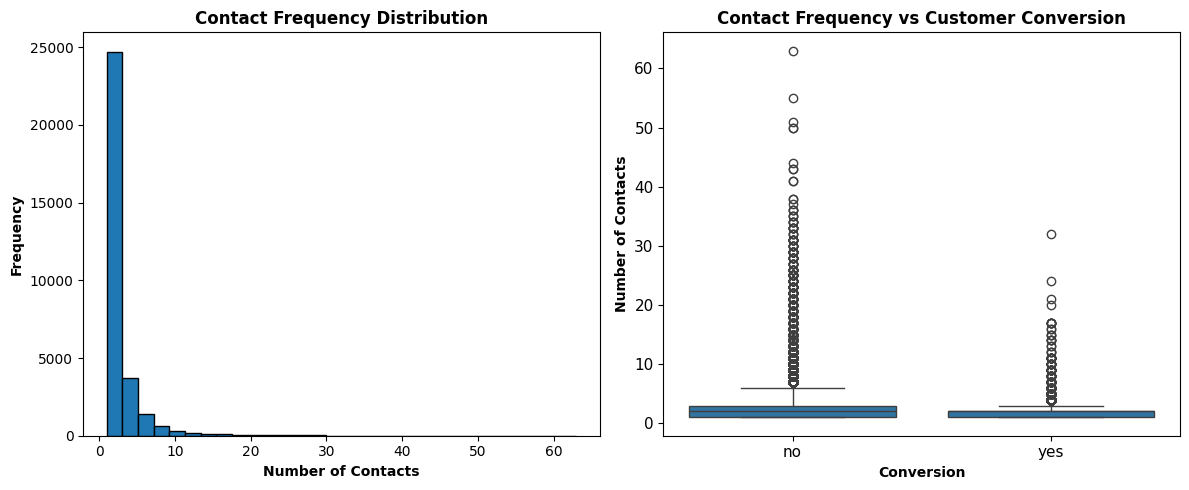

In [28]:
# Distribution and Conversion Analysis of Campaign Contact Frequency

plt.figure(figsize=(12,5))

# Histogram (Distribution)
plt.subplot(1,2,1)
plt.hist(data['numberOfContacts'], bins=30, edgecolor='black')
plt.title('Contact Frequency Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Number of Contacts', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')

# Boxplot (vs Target)
plt.subplot(1,2,2)
sns.boxplot(x='target', y='numberOfContacts', data=data)
plt.title('Contact Frequency vs Customer Conversion', fontsize=12, fontweight='bold')
plt.xlabel('Conversion', fontweight='bold')
plt.ylabel('Number of Contacts', fontweight='bold')

# Tick styling (clean look)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

### Key Insights :
- Customer contact frequency is highly skewed toward lower values, with most customers contacted fewer than 5 times.
- Customers who converted generally have slightly lower contact frequency compared to non-converted customers.
- Non-converted customers show a wider distribution with many high-frequency outliers.
- Excessive contact attempts (above ~10 contacts) are mostly associated with non-conversion, indicating diminishing returns.
- Moderate contact improves engagement, but very high contact frequency negatively impacts customer response.

### Business Implication :
- Repeated and excessive contact strategies are inefficient and may lead to customer fatigue.
- Businesses should prioritize quality and timing of communication over quantity.
- Maintaining an optimal contact range (around 2–5 attempts) can improve efficiency and reduce costs.
- Instead of repeatedly targeting the same customers, campaigns should focus on better segmentation and smarter targeting.
- Optimizing contact strategy can significantly improve overall campaign conversion performance.

### Impact of Account Balance on Customer Conversion

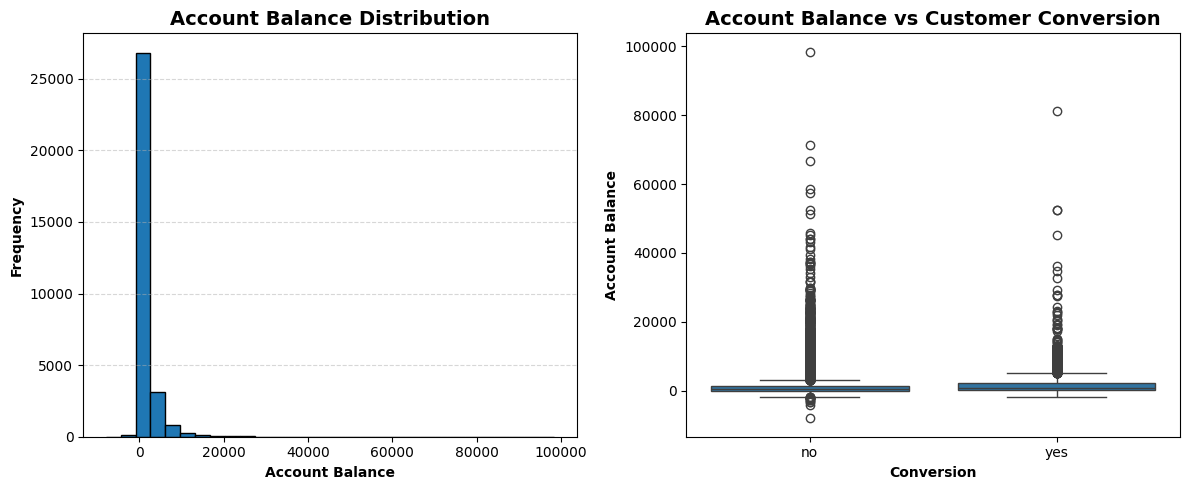

In [29]:


plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
plt.hist(data['accountBalance'], bins=30, edgecolor='black')
plt.title('Account Balance Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Account Balance', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=data['target'], y=data['accountBalance'])
plt.title('Account Balance vs Customer Conversion', fontsize=14, fontweight='bold')
plt.xlabel('Conversion', fontweight='bold')
plt.ylabel('Account Balance', fontweight='bold')

plt.tight_layout()
plt.show()

### Key Insights :
- The distribution of account balance is highly right-skewed, with most customers having low to moderate balances and a few extreme high-value outliers.
- A significant number of customers have balances close to zero or even negative, indicating limited financial capacity for a large portion of the        dataset.
- Customers who converted generally show slightly higher account balances compared to non-converted customers.
- The boxplot indicates that higher balance customers tend to have a higher median value in the conversion group.
- However, the presence of many outliers suggests that account balance alone is not a strong standalone predictor of conversion.

### Business Implication :
- Customers with higher account balances are more likely to convert, making them a valuable target segment for marketing campaigns.
- Financial capacity plays a role in conversion, so campaigns can be optimized by prioritizing customers with moderate to high balances.
- However, since the relationship is not very strong, account balance should be combined with other features (like call duration or campaign outcome)     for better targeting.
- Special strategies may be needed for low-balance customers, such as offering smaller or more flexible financial products.
- Businesses should avoid relying solely on balance and instead use it as part of a broader customer profiling strategy.

### Impact of Age on Customer Conversion

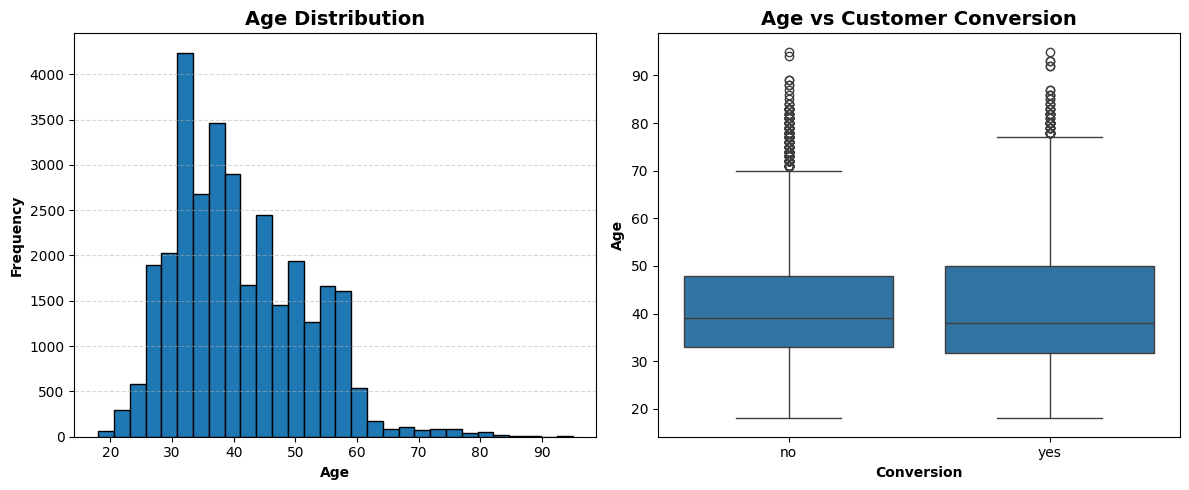

In [30]:

plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
plt.hist(data['age'], bins=30, edgecolor='black')

plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=data['target'], y=data['age'])

plt.title('Age vs Customer Conversion', fontsize=14, fontweight='bold')
plt.xlabel('Conversion', fontweight='bold')
plt.ylabel('Age', fontweight='bold')

plt.tight_layout()
plt.show()

### Key Insights :
- The age distribution is approximately normal, with a higher concentration of customers in the middle-age range (around 30–50 years).
- The histogram shows a balanced spread without extreme skewness, indicating a well-distributed customer base across age groups.
- From the boxplot, there is no significant difference in age distribution between converted and non-converted customers.
- The median age for both groups is very similar, suggesting minimal variation in conversion behavior across age segments.
- Overall, age does not appear to strongly influence customer conversion.

### Business Implication :
- Age should not be considered a primary factor when targeting customers for marketing campaigns.
- Campaign strategies should focus more on behavioral and interaction-based features (e.g., call duration, campaign outcome) rather than demographic      factors like age.
- Since all age groups behave similarly, campaigns can be designed to be broadly applicable rather than age-specific.
- Resources should be allocated toward features that show stronger impact on conversion to maximize campaign effectiveness.
- Age can still be used for basic segmentation, but not as a key decision-making variable.

### Detailed Analysis

- University graduates show strongest performance  
- High school customers form large segment  
- Secondary school customers show weakest response  
- Unknown group shows moderate performance  
- Conversion varies across education levels  

##  Final Conclusion

The analysis of this marketing campaign reveals that success is not random; it is driven by specific **behavioral patterns** and **historical engagement**. While the overall conversion rate stands at approximately **11.8%**, certain sub-groups perform significantly better. 

We have identified that **Call Duration** and **Previous Campaign Success** are the two most influential factors in determining whether a customer will subscribe. Demographic factors like education and job type play a supporting role, but the "human element"—how long a customer stays on the phone and their past relationship with the bank—is what truly moves the needle. By transitioning from a broad "mass-marketing" approach to a "data-driven" targeted strategy, the bank can significantly reduce costs and increase the conversion rate.

## Strategic Summary & Action Plan

Based on the data, here is the recommended 3-step strategy for future campaigns:

1.  **Prioritize High-Propensity Leads:** * Focus the sales team on customers who had a **'Success'** outcome in the previous campaign. 
    * Target **University graduates** and those without **housing loans**, as these segments show the highest financial readiness.


2.  **Optimize Engagement Quality:**
    * Since **longer call durations** correlate with conversion, sales scripts should be redesigned to focus on relationship-building rather than quick pitches. 
    * Calls lasting under 2 minutes have a very low success rate; the goal should be to cross the "engagement threshold" found in the EDA.


3.  **Reduce Resource Wastage:**
    * Stop repeated contact attempts after the **4th or 5th contact**. The data shows that conversion probability drops significantly after this point, and continued outreach may lead to brand fatigue.
    * Avoid aggressive targeting of customers with existing high-debt profiles (housing/personal loans) unless they have a history of previous campaign success.